# Manipulação de grafos

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>

<hr>

Um **grafo** (ou **rede**) é uma estrutura matemática usada para representar **relações entre objetos**: uma malha de amigos nas redes sociais, as ligações entre proteínas em uma célula, os hyperlinks entre páginas da internet, as rotas aéreas entre aeroportos, as citações entre artigos científicos. Praticamente qualquer sistema composto por "objetos" e "conexões entre objetos" pode ser modelado como uma rede. O estudo sistemático dessas estruturas, como elas se formam, quais padrões emergem e como isso afeta fenômenos como a disseminação de uma doença ou de uma informação, é o campo da **Ciência de Redes**.

Formalmente, um grafo $G = (V, E)$ é definido por:

- um conjunto de **vértices** (ou nós) $V$ — os "objetos" da rede;
- um conjunto de **arestas** (ou links/conexões) $E$ — os pares de vértices que estão relacionados entre si.

Algumas distinções fundamentais que valem a pena ter em mente desde já, e que vamos explorar na prática ao longo deste notebook:

- **grafos não direcionados vs. direcionados**: em um grafo não direcionado, uma aresta entre A e B representa uma relação simétrica (uma amizade, por exemplo); em um grafo direcionado (ou *dígrafo*), a aresta tem um sentido (A segue B em uma rede social, mas B não necessariamente segue A de volta);
- **grafos não ponderados vs. ponderados**: em um grafo ponderado, cada aresta carrega um número (peso) que mede a intensidade da relação. Por exemplo, quantas vezes duas pessoas trocaram mensagens;

Neste notebook, vamos aprender a **construir, manipular, visualizar, converter, ler e escrever** grafos usando a biblioteca **NetworkX**, a ferramenta padrão em Python para análise de redes. Para a sua instalação, veja: https://networkx.org/documentation/stable/install.html

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

## Criando e manipulando um grafo

Vamos começar pelo mais simples: um **grafo vazio**, sem nenhum vértice ou aresta. A partir dele, vamos incluir vértices e conexões aos poucos, para ver o efeito de cada operação.

In [ ]:
G = nx.Graph()

Podemos incluir alguns vértices, cada um identificado por um nome (aqui, uma string):

In [ ]:
G.add_node('Node1')
G.add_node('Node2')
G.add_node('Node3')
G.add_node('Node4')
G.add_node('Node5')
G.add_node('Node6')

E também algumas arestas, cada uma conectando um par de vértices já existentes:

In [ ]:
G.add_edge('Node1','Node2')
G.add_edge('Node2','Node3')
G.add_edge('Node1','Node3')
G.add_edge('Node2','Node4')
G.add_edge('Node3','Node5')
G.add_edge('Node5','Node6')

### Visualizando o grafo

A função `nx.draw` desenha o grafo. Como um grafo não tem uma posição espacial natural, precisamos escolher um **algoritmo de layout** que decide onde posicionar cada vértice no desenho, sendo `nx.spring_layout`  um dos mais usados: ele simula um sistema físico de molas (arestas) empurrando e puxando os vértices até uma disposição visualmente equilibrada, com vértices conectados tendendo a ficar próximos entre si.

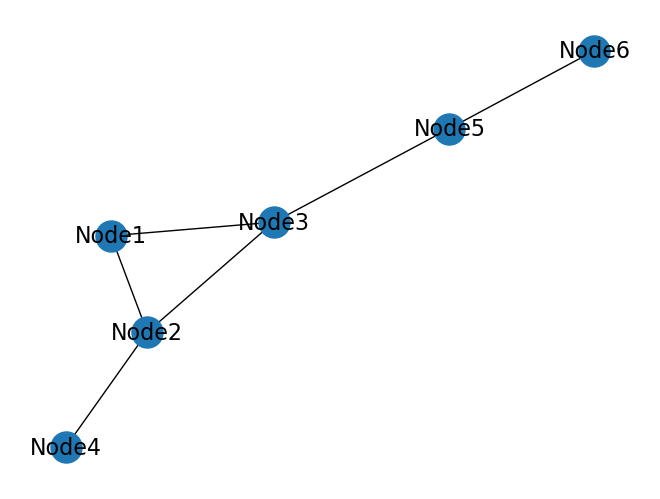

In [ ]:
pos = nx.spring_layout(G)
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

### Removendo arestas e vértices

Fixamos a posição `pos` calculada acima (em vez de recalculá-lo) para que os vértices remanescentes não "pulem" de posição entre um desenho e outro. Assim conseguimos comparar visualmente o antes e o depois de cada remoção. Vamos remover as arestas do vértice 1:

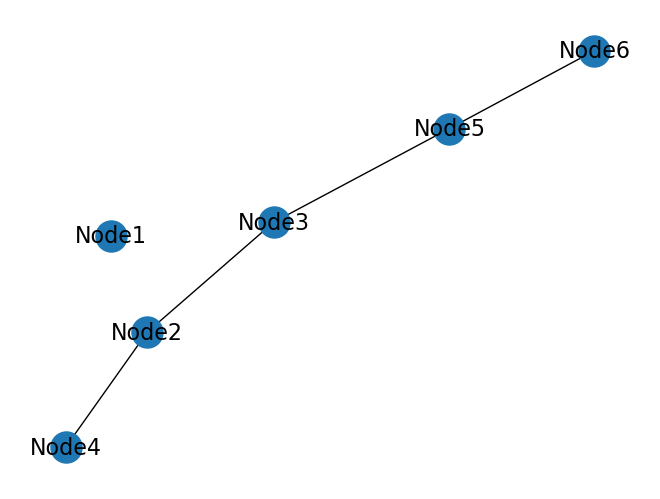

In [ ]:
G.remove_edge('Node1','Node2')
G.remove_edge('Node1','Node3')
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

Note que o `Node1` continua no grafo, apenas **isolado** (sem nenhuma aresta). Remover uma aresta não remove os vértices que ela conectava. Para remover um vértice por completo (e, com ele, todas as arestas que o tocam), usamos `remove_node`:

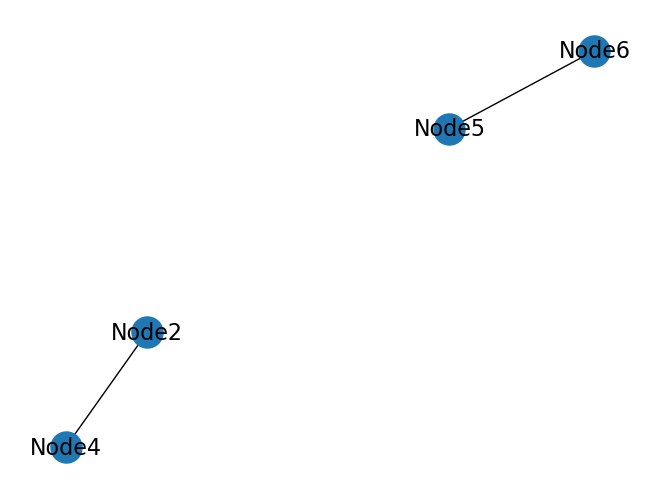

In [ ]:
G.remove_node('Node1')
G.remove_node('Node3')
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

## Grafos ponderados

Em muitas redes reais, nem todas as conexões têm a mesma "força": duas pessoas podem trocar poucas ou muitas mensagens, dois aeroportos podem ter poucos ou muitos voos diretos entre si. Para capturar essa informação, associamos um **peso** (`weight`) a cada aresta, criando um **grafo ponderado**.

In [ ]:
Gw = nx.Graph()

Gw.add_edge('a', 'b', weight=0.1)
Gw.add_edge('a', 'c', weight=0.5)
Gw.add_edge('b', 'c', weight=0.3)
Gw.add_edge('a', 'd', weight=0.9)

Ao desenhar, podemos usar `nx.draw_networkx_edge_labels` para exibir o peso de cada aresta sobre o desenho:

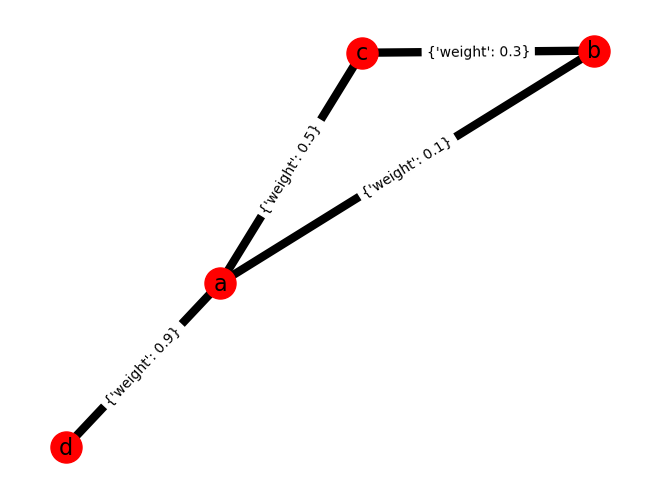

In [ ]:
posw = nx.spring_layout(Gw)
nx.draw(Gw, with_labels=True, node_color='r', node_size=500,
        font_size=16, pos=posw, width=6)
nx.draw_networkx_edge_labels(Gw, posw)   # usa os rótulos padrão (o peso de cada aresta)
plt.show()

### Adicionando novas conexões

Note que `add_edge` cria automaticamente os vértices que ainda não existirem no grafo (aqui, os vértices `1` e `2`). Também é possível adicionar uma aresta **sem** especificar um peso.

In [ ]:
Gw.add_edge(1, 2, weight=4.0)
Gw.add_edge(1, 'a')   # esta aresta não tem peso definido

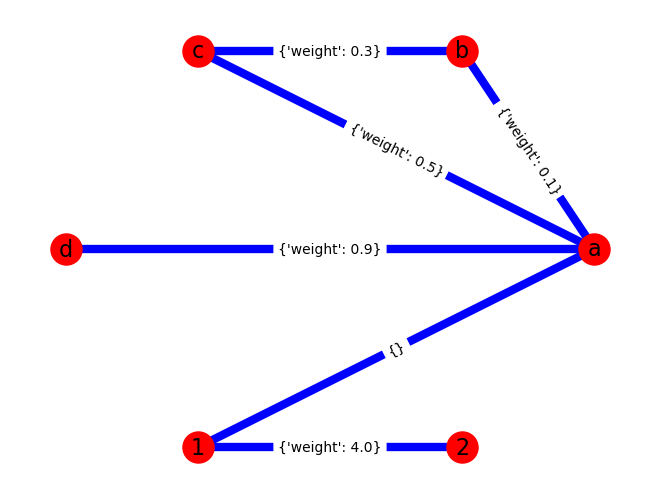

In [ ]:
pos = nx.circular_layout(Gw)
nx.draw(Gw, with_labels=True, node_color='r', edge_color='b',
        node_size=500, font_size=16, pos=pos, width=6)
nx.draw_networkx_edge_labels(Gw, pos)
plt.show()

Note que a aresta entre `1` e `'a'` não apresenta o valor do peso no desenho. Como não foi definido um peso para ela, não há nada para `draw_networkx_edge_labels` exibir sobre essa conexão específica.

## Matriz de adjacências e lista de conexões

Além de adicionar vértices e arestas um a um, um grafo pode ser construído diretamente a partir de outras representações matemáticas equivalentes. Duas das mais comuns são a **matriz de adjacências** e a **lista de arestas**.

A **matriz de adjacências** $A$ é uma matriz $n \times n$ (sendo $n$ o número de vértices), em que $A_{ij} = 1$ se existe uma aresta entre os vértices $i$ e $j$, e $A_{ij}=0$ caso contrário (para grafos ponderados, $A_{ij}$ guarda o peso da aresta em vez de apenas 0/1). É uma representação densa, conveniente para cálculos matriciais, mas que desperdiça memória em redes grandes e esparsas (com poucas conexões em relação ao número possível).

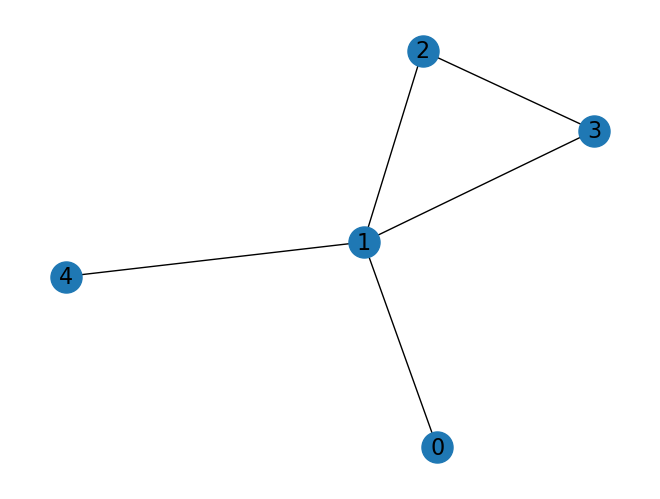

In [ ]:
import numpy as np

A = np.array([
    [0, 1, 0, 0, 0],
    [1, 0, 1, 1, 1],
    [0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0],
    [0, 1, 0, 0, 0]
])

# nx.from_numpy_array converte uma matriz de adjacências (array do NumPy) em um objeto Graph do NetworkX
# (em versões antigas do NetworkX, essa função se chamava from_numpy_matrix -- hoje descontinuada)
G = nx.from_numpy_array(A)

pos = nx.spring_layout(G)
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

A **lista de arestas** (*edge list*), por outro lado, é simplesmente uma lista de pares de vértices conectados — uma representação mais compacta, especialmente para redes esparsas (a maioria das redes reais). De maneira similar à matriz de adjacências, também podemos construir um grafo diretamente a partir de uma lista de arestas:

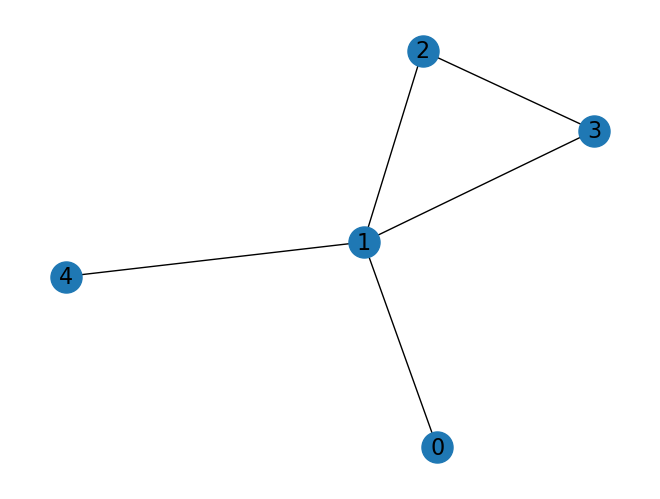

In [ ]:
G.clear()   # esvazia o grafo (remove todos os vértices e arestas), para reutilizar a variável G
edgelist = [(0, 1), (1, 2), (2, 3), (3, 1), (4, 1)]
G = nx.Graph(edgelist)
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

### Grafos direcionados

A mesma lista de arestas pode ser interpretada como um grafo **direcionado** (ou *dígrafo*), bastando usar a classe `nx.DiGraph` em vez de `nx.Graph`. Note, no desenho abaixo, as setas indicando o sentido de cada conexão — em `(0,1)`, por exemplo, existe uma ligação de `0` para `1`, mas não necessariamente de `1` para `0`.

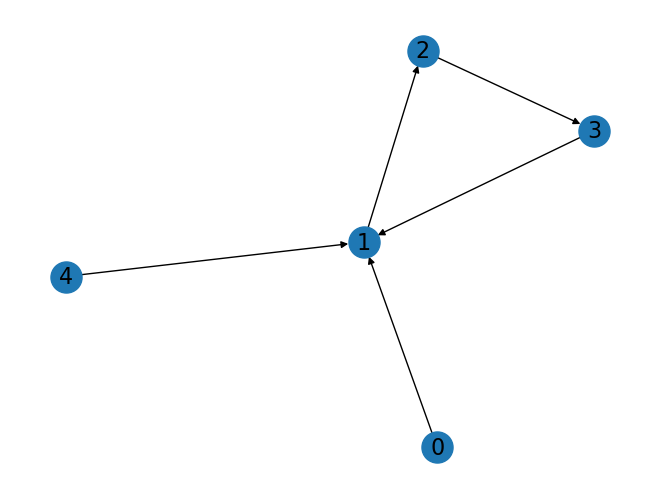

In [ ]:
G.clear()
edgelist = [(0, 1), (1, 2), (2, 3), (3, 1), (4, 1)]
G = nx.DiGraph(edgelist)
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

## Acesso a vértices e arestas

Além de construir e visualizar grafos, precisamos saber **consultar** as informações neles armazenadas: quais atributos um vértice ou aresta específica possui, percorrer todos os vértices/arestas em um laço, ou modificar atributos em massa. Vamos construir um novo grafo, desta vez guardando também alguns **atributos** nos vértices e arestas (por exemplo, um horário `time`), e ver como acessá-los.

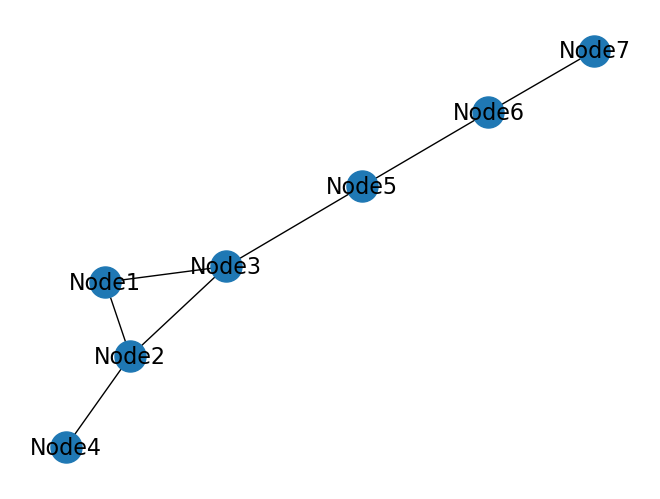

In [ ]:
G = nx.Graph()
G.add_node('Node1')
G.add_node('Node2')
G.add_node('Node3')
G.add_node('Node4')
G.add_node('Node5')
G.add_node('Node6')
G.add_edge('Node1', 'Node2', time='10pm')
G.add_edge('Node2', 'Node3')
G.add_edge('Node1', 'Node3')
G.add_edge('Node2', 'Node4')
G.add_edge('Node3', 'Node5')
G.add_edge('Node5', 'Node6')

G.add_node('Node7', time='5pm')
G.add_edge('Node7', 'Node6')

pos = nx.spring_layout(G)
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

### Acessando um vértice específico

`G.nodes[nome_do_vertice]` devolve um **dicionário** com os atributos daquele vértice — no caso de `'Node7'`, incluindo o atributo `time` que definimos acima.

In [ ]:
print(G.nodes['Node7'])  # dicionário Python

{'time': '5pm'}


### Acessando uma aresta específica

Da mesma forma, `G.edges[u, v]` devolve os atributos da aresta entre `u` e `v`:

In [ ]:
print(G.edges['Node1', 'Node2'])  # dicionário Python

{'time': '10pm'}


### Iterando sobre vértices e arestas

Muitas aplicações precisam **percorrer** todos os vértices ou arestas de um grafo — por exemplo, para calcular alguma métrica para cada um deles.

In [ ]:
for node in G.nodes():
    print('Vértice:', node)

Vértice: Node1
Vértice: Node2
Vértice: Node3
Vértice: Node4
Vértice: Node5
Vértice: Node6
Vértice: Node7


### Renomeando vértices para inteiros

Alguns algoritmos e formatos de arquivo trabalham melhor com vértices identificados por **números inteiros sequenciais** (em vez de nomes como `'Node1'`). A função `convert_node_labels_to_integers` faz exatamente essa conversão, relabelando os vértices a partir de um valor inicial (`first_label`).

In [ ]:
G = nx.convert_node_labels_to_integers(G, first_label=0)
for node in G.nodes():
    print('Vértice:', node)

Vértice: 0
Vértice: 1
Vértice: 2
Vértice: 3
Vértice: 4
Vértice: 5
Vértice: 6


### Acessando arestas com seus atributos

Passando `data=True`, cada aresta é devolvida como uma tupla `(u, v, atributos)`, incluindo o dicionário de atributos daquela conexão.

In [ ]:
for aresta in G.edges(data=True):
    print(aresta)

(0, 1, {'time': '10pm'})
(0, 2, {})
(1, 2, {})
(1, 3, {})
(2, 4, {})
(4, 5, {})
(5, 6, {})


### Modificando atributos em massa

Podemos também **atribuir** (ou sobrescrever) um atributo para todas as arestas de uma vez, percorrendo o grafo em um laço — aqui, definindo o mesmo peso (`1.5`) para todas as conexões.

In [ ]:
for edge in G.edges():
    G[edge[0]][edge[1]]['weight'] = 1.5

# Conferindo o resultado:
for aresta in G.edges(data=True):
    print(aresta)

(0, 1, {'time': '10pm', 'weight': 1.5})
(0, 2, {'weight': 1.5})
(1, 2, {'weight': 1.5})
(1, 3, {'weight': 1.5})
(2, 4, {'weight': 1.5})
(4, 5, {'weight': 1.5})
(5, 6, {'weight': 1.5})


## Operadores para grafos

Vamos limpar o grafo anterior e explorar algumas operações que combinam ou extraem partes de um grafo.

In [ ]:
G.clear()
print(G.nodes())
print(G.edges)

[]
[]


### Subgrafos

Um **subgrafo** é a porção de um grafo restrita a um subconjunto de vértices (e às arestas que conectam apenas vértices desse subconjunto). Vamos usar a famosa rede do **clube de caratê de Zachary** — um estudo clássico de 1977 sobre as amizades entre os 34 membros de um clube universitário, hoje um dos exemplos mais usados para ilustrar conceitos de redes complexas — e extrair dela um subgrafo. Note que `'node test'` não aparece destacado no resultado, porque esse vértice não existe no grafo original.

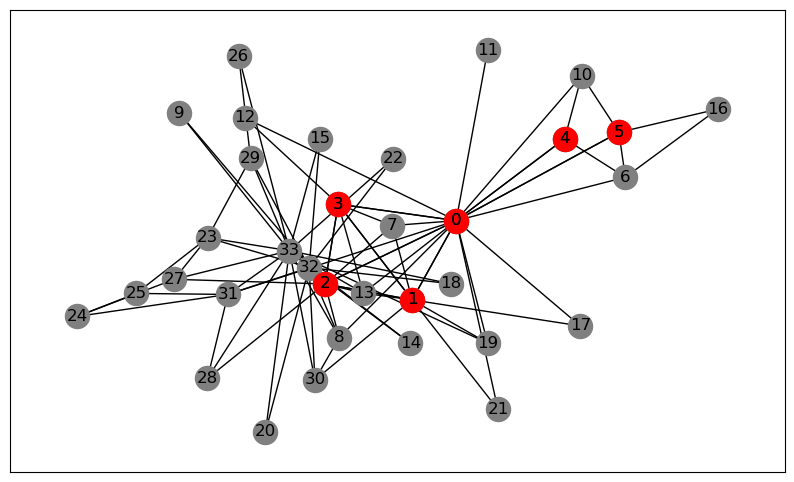

In [ ]:
G = nx.karate_club_graph()
subset = [0, 1, 2, 3, 4, 5, 'node test']   # um conjunto de vértices (um deles inexistente)
pos = nx.spring_layout(G)   # calculamos o layout a partir de G, não do subgrafo, para manter a referência espacial
k = G.subgraph(subset)

plt.figure(figsize=(10, 6))
nx.draw_networkx(G, pos=pos, node_color='gray')
nx.draw_networkx(k, pos=pos, node_color='red')
plt.show()

### União de grafos

Podemos juntar dois grafos usando a operação de **união**. O comando `disjoint_union` assume que todos os vértices dos dois grafos são **diferentes** — mesmo que os grafos originais usem os mesmos rótulos (por exemplo, `0, 1, 2` em ambos), a união os trata como vértices distintos, renomeando-os automaticamente para evitar conflitos. Vamos criar dois grafos pequenos:

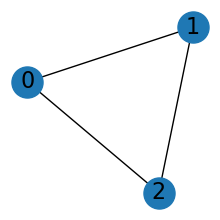

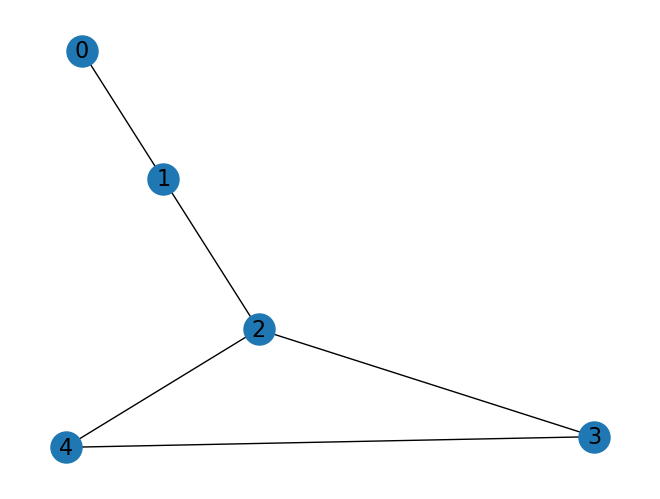

In [ ]:
plt.figure(figsize=(2, 2))
G0 = nx.Graph([(0, 1), (1, 2), (2, 0)])
nx.draw(G0, with_labels=True, node_size=500, font_size=16)
plt.show()

G1 = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 4), (2, 4)])
nx.draw(G1, with_labels=True, node_size=500, font_size=16)
plt.show()

Aplicando o comando `disjoint_union` para criar um terceiro grafo, combinando os dois anteriores:

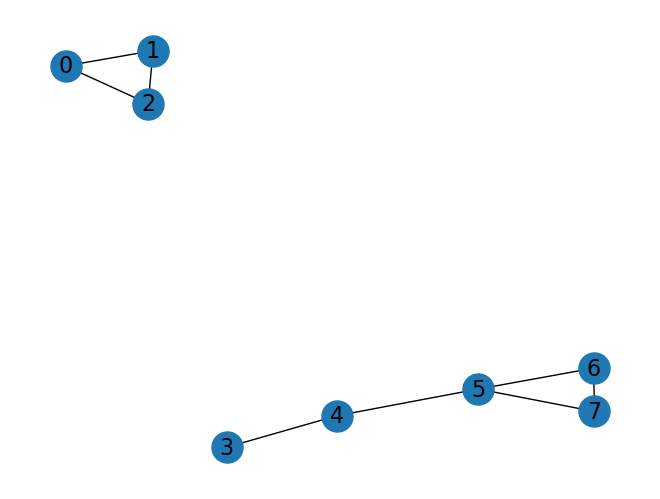

In [ ]:
G2 = nx.disjoint_union(G0, G1)
nx.draw(G2, with_labels=True, node_size=500, font_size=16)
plt.show()

Note que os rótulos mudaram, e agora o grafo resultante tem 7 vértices (os 3 de `G0` mais os 5 de `G1` — sem sobreposição, mesmo que os rótulos originais coincidissem).

In [ ]:
print('Vértices:', G2.nodes())
print('Arestas:', G2.edges())

Vértices: [0, 1, 2, 3, 4, 5, 6, 7]
Arestas: [(0, 1), (0, 2), (1, 2), (3, 4), (4, 5), (5, 6), (5, 7), (6, 7)]


### Composição de grafos

Uma alternativa à união é a **composição** (`nx.compose`): nesse caso, vértices com o **mesmo rótulo** em grafos diferentes são considerados como sendo **o mesmo vértice**, e suas conexões se combinam — diferente da união disjunta, aqui os rótulos compartilhados **não** são renomeados.

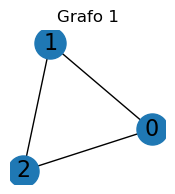

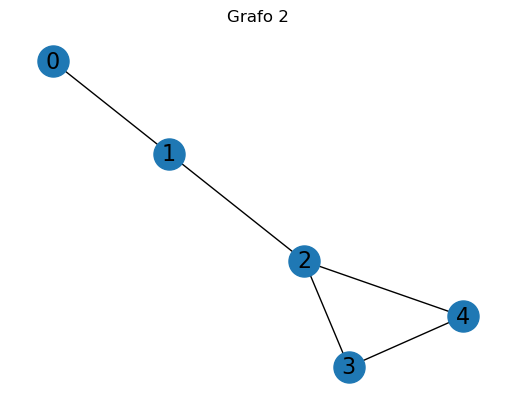

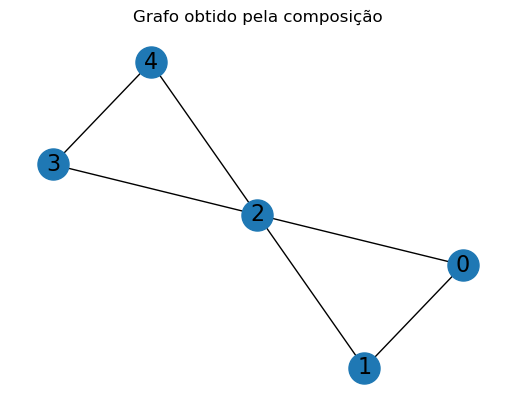

In [ ]:
plt.figure(figsize=(2, 2))
G1 = nx.Graph([(0, 1), (1, 2), (2, 0)])
plt.title('Grafo 1')
nx.draw(G1, with_labels=True, node_size=500, font_size=16)
plt.show()

G2 = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 4), (2, 4)])
plt.title('Grafo 2')
nx.draw(G2, with_labels=True, node_size=500, font_size=16)
plt.show()

G3 = nx.compose(G1, G2)
plt.title('Grafo obtido pela composição')
nx.draw(G3, with_labels=True, node_size=500, font_size=16)
plt.show()

Note que o grafo resultante da composição tem apenas **5** vértices (0 a 4) — os vértices `0`, `1` e `2`, presentes nos dois grafos originais, foram tratados como o mesmo vértice, e suas conexões de ambos os grafos foram preservadas.

## Conversão entre tipos de grafos

É comum precisar converter um grafo de um tipo para outro — por exemplo, ignorar o sentido das arestas de um grafo direcionado, ou o contrário. Para converter um grafo **direcionado** (dígrafo) em um grafo **sem direção**, usamos o método `.to_undirected()`:

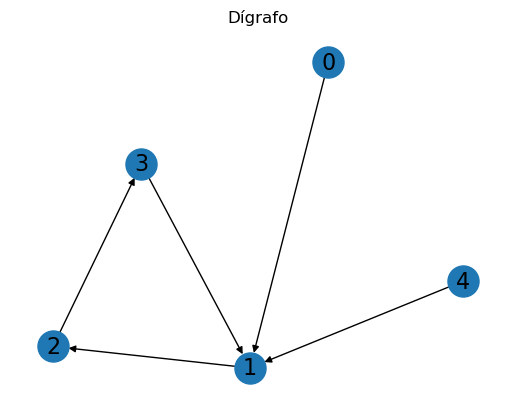

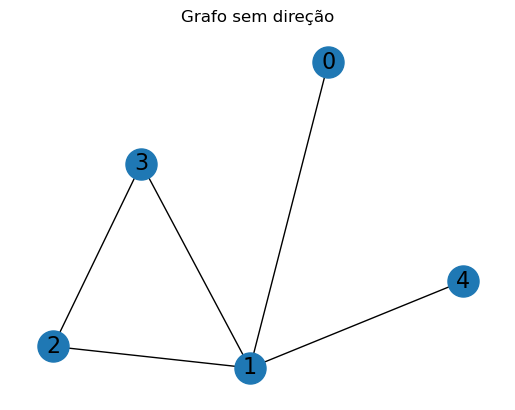

In [ ]:
edgelist = [(0, 1), (1, 2), (2, 3), (3, 1), (4, 1)]
G = nx.DiGraph(edgelist)
pos = nx.spring_layout(G)
plt.title('Dígrafo')
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

G = G.to_undirected()
plt.title('Grafo sem direção')
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

Podemos ainda fazer o inverso: converter um grafo sem direção para um grafo com arestas direcionadas, usando `.to_directed()`.

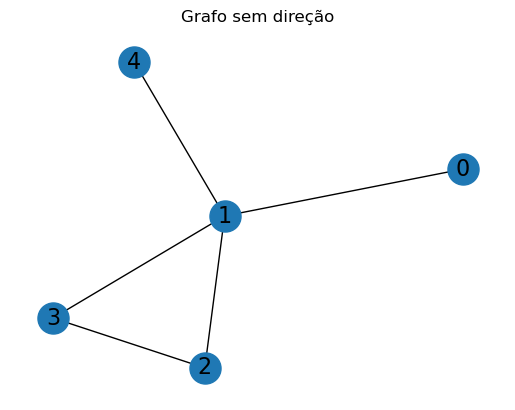

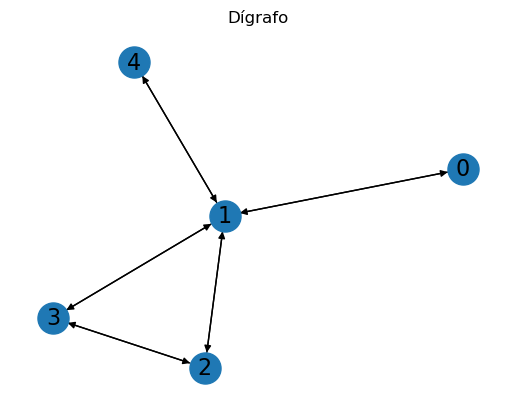

In [ ]:
edgelist = [(0, 1), (1, 2), (2, 3), (3, 1), (4, 1)]
G = nx.Graph(edgelist)
pos = nx.spring_layout(G)
plt.title('Grafo sem direção')
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

G = G.to_directed()
plt.title('Dígrafo')
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

Note que, ao converter um grafo sem direção para um dígrafo, cada aresta original vira **duas** arestas direcionadas (uma em cada sentido) — afinal, uma conexão simétrica $A-B$ corresponde exatamente a $A \to B$ **e** $B \to A$ ao mesmo tempo.

### Removendo os pesos de um grafo (por um limiar)

Outra conversão comum: transformar um grafo **ponderado** em um grafo **binário** (sem pesos), mantendo apenas as conexões cujo peso ultrapassa um determinado **limiar** (*threshold*). Isso é útil, por exemplo, para simplificar uma rede muito densa, mantendo só as conexões mais fortes.

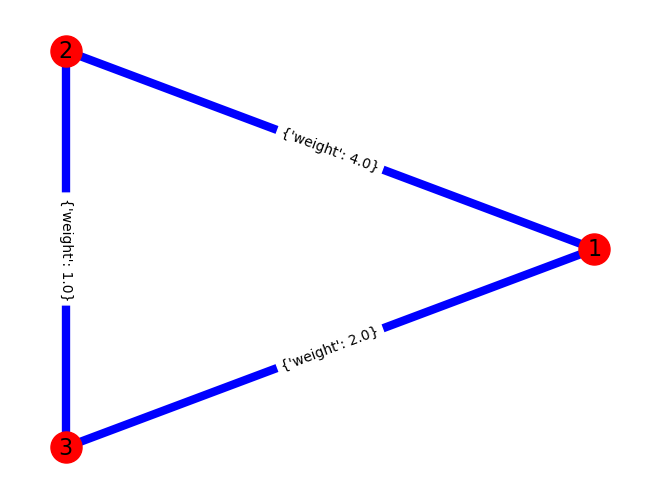

In [ ]:
G1 = nx.Graph()
G1.add_edge(1, 2, weight=4.0)
G1.add_edge(1, 3, weight=2.0)
G1.add_edge(2, 3, weight=1.0)

pos = nx.circular_layout(G1)
nx.draw(G1, with_labels=True, node_color='r', edge_color='b',
        node_size=500, font_size=16, pos=pos, width=6)
nx.draw_networkx_edge_labels(G1, pos)
plt.show()

Definimos um peso mínimo (`min_weight`): arestas cujo peso seja **maior** que esse valor são mantidas (sem o peso original, apenas como conexão binária); as demais são descartadas.

In [ ]:
min_weight = 1.0
Gnew = nx.Graph()
for (u, v, w) in G1.edges(data=True):
    if w['weight'] > min_weight:
        Gnew.add_edge(u, v, weight=1)

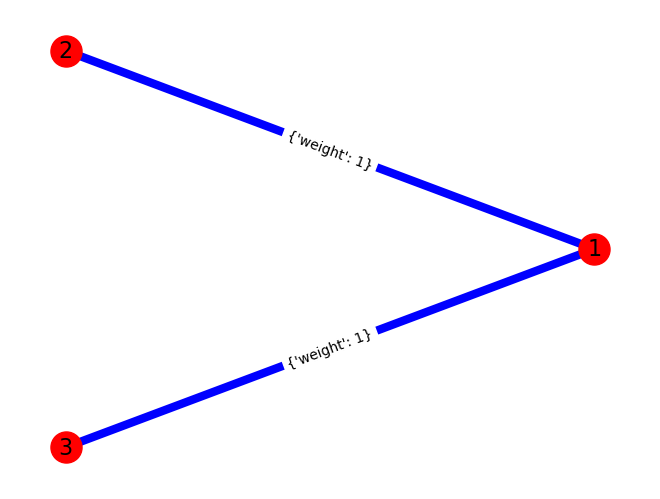

In [ ]:
nx.draw(Gnew, with_labels=True, node_color='r', edge_color='b',
        node_size=500, font_size=16, pos=pos, width=6)
nx.draw_networkx_edge_labels(Gnew, pos)
plt.show()

Note que a aresta entre 2 e 3 (peso 1.0, não estritamente maior que `min_weight=1.0`) foi descartada — restaram apenas as duas conexões com peso originalmente maior que o limiar.

## Leitura e escrita de arquivos

Redes reais quase sempre vêm de um arquivo (obtido de uma base de dados, um artigo científico, uma coleta própria...), não são construídas manualmente vértice a vértice como fizemos até aqui. O NetworkX oferece funções de leitura e escrita para vários formatos: `g = nx.read_formato("caminho/arquivo", ...)` para ler, e `nx.write_formato(g, "caminho/arquivo", ...)` para escrever (sendo `formato` um padrão como *edgelist*, GML, GraphML, Pajek, entre outros).

Vamos usar novamente a rede do clube de caratê de Zachary, desta vez para demonstrar o ciclo completo de salvar e recarregar um grafo.

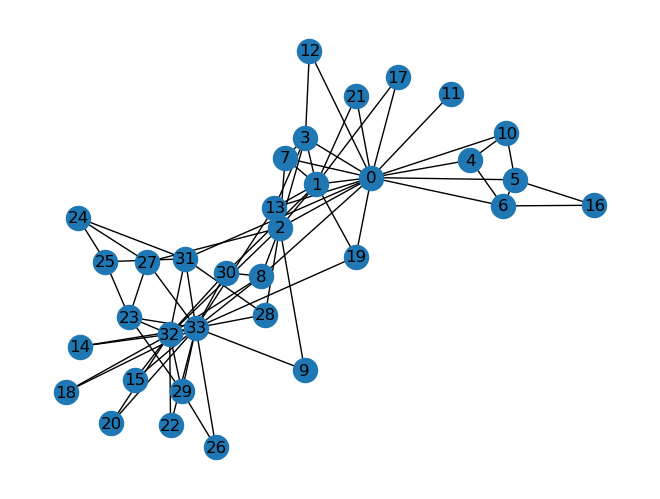

In [ ]:
G = nx.karate_club_graph()
nx.draw(G, with_labels=True)
plt.show()

Salvando essa rede em um arquivo, no formato de lista de arestas (*edge list*):

In [ ]:
nx.write_edgelist(G, "zachary.txt")

Podemos então fazer a leitura do arquivo e reconstruir a rede a partir dele:

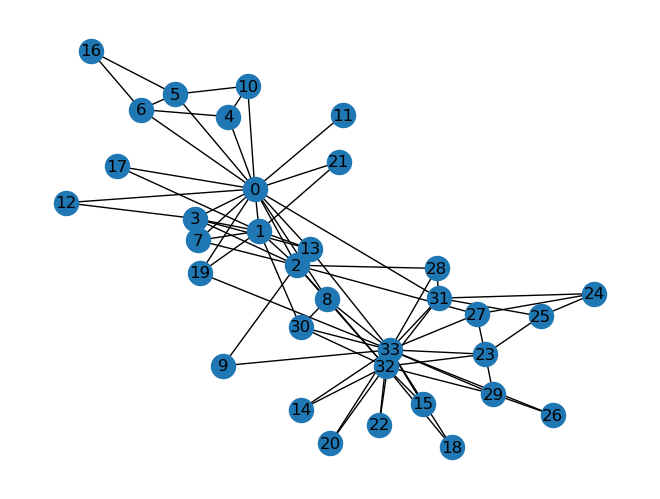

In [ ]:
Gnew = nx.read_edgelist("zachary.txt")
nx.draw(Gnew, with_labels=True)
plt.show()

Outros formatos também podem ser considerados, como GML, Pajek ou matriz de adjacências. Uma lista completa de formatos suportados pode ser vista na documentação oficial: https://networkx.org/documentation/stable/reference/readwrite/index.html

## Componentes conectados

Algumas redes não formam um único bloco conectado — elas se dividem em vários **componentes**, grupos de vértices conectados entre si, mas sem nenhuma conexão com vértices de outros grupos. Isso é comum, por exemplo, em redes sociais reais (grupos de amigos completamente isolados de outros grupos) ou em redes de citação (áreas de pesquisa que nunca se citam mutuamente).

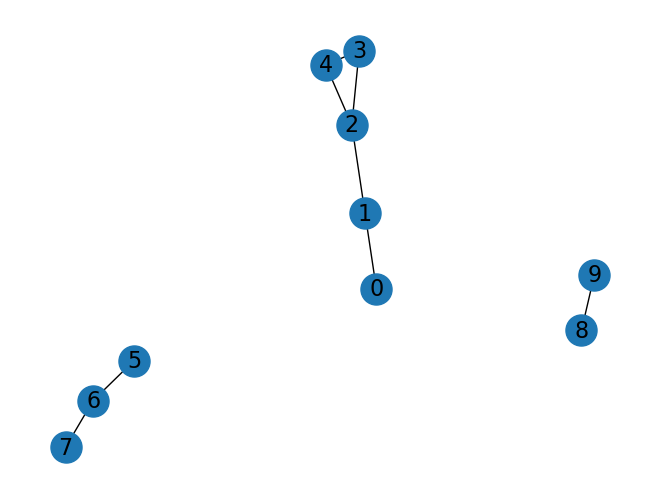

In [ ]:
G = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 4), (2, 4), (5, 6), (6, 7), (8, 9)])
pos = nx.fruchterman_reingold_layout(G)   # um algoritmo de layout equivalente ao spring_layout
nx.draw(G, with_labels=True, node_size=500, font_size=16, pos=pos)
plt.show()

Visualmente já dá para notar três grupos isolados. Para obter os componentes de forma programática (ordenados do maior para o menor):

In [ ]:
Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
print(Gcc[0])
print(Gcc[1])
print(Gcc[2])

{0, 1, 2, 3, 4}
{5, 6, 7}
{8, 9}


Para obter apenas o **maior componente** (frequentemente usado como um pré-processamento padrão, descartando fragmentos pequenos e mantendo só o "núcleo" conectado da rede):

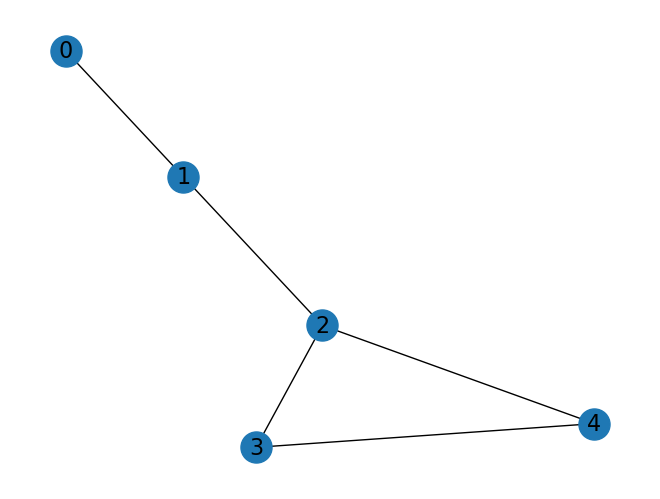

In [ ]:
Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
G0 = G.subgraph(Gcc[0])
nx.draw(G0, with_labels=True, node_size=500, font_size=16)
plt.show()

### Removendo todas as arestas de um vértice específico

Por fim, um exemplo prático que combina vários conceitos já vistos: gerar uma rede aleatória, extrair seu maior componente, e então remover **todas as conexões de um vértice escolhido ao acaso** (mantendo o vértice, agora isolado, na rede) — uma operação comum em simulações de robustez de redes, por exemplo, para estudar o efeito de "desconectar" um nó importante.

[0, 2, 4, 7, 8, 9]


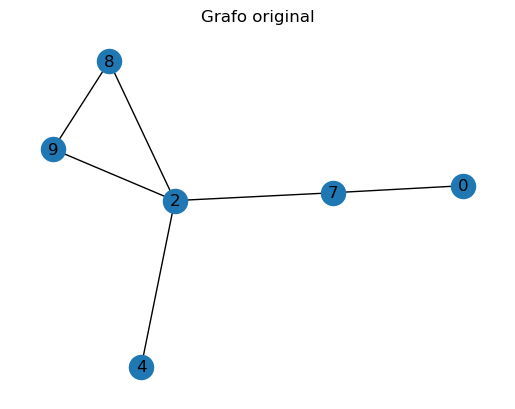

Vértice escolhido: 7


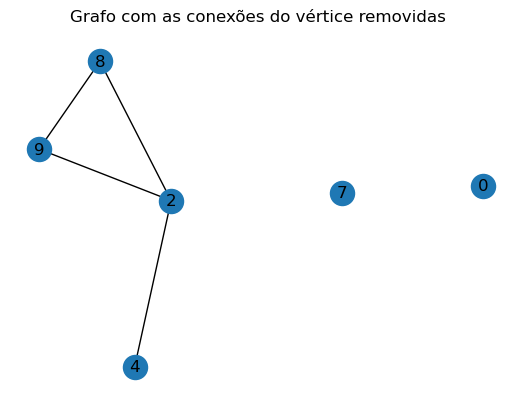

[0, 2, 4, 7, 8, 9]


In [ ]:
import numpy as np
import random

def remove_node_edges(G, i):
    """Remove todas as arestas que tocam o vértice i, sem remover o próprio vértice."""
    vizinhos = G.neighbors(i)
    arestas_a_remover = [[i, j] for j in vizinhos]
    G.remove_edges_from(arestas_a_remover)


N = 10       # número de vértices
p = 0.2      # probabilidade de conexão entre cada par de vértices
G = nx.gnp_random_graph(N, p, seed=None, directed=False)

# Extrai o maior componente conectado
Gcc = sorted(nx.connected_components(G), key=len, reverse=True)
G0 = G.subgraph(Gcc[0])
G0 = nx.Graph(G0)   # copia o subgrafo para um novo objeto Graph, editável livremente

print(G0.nodes())
pos = nx.fruchterman_reingold_layout(G0)
plt.title('Grafo original')
nx.draw(G0, pos=pos, with_labels=True)
plt.show()

# Remove as conexões de um vértice escolhido aleatoriamente
vertice_sorteado = random.choice(np.array(G0.nodes()))
print('Vértice escolhido:', vertice_sorteado)
remove_node_edges(G0, vertice_sorteado)

plt.title('Grafo com as conexões do vértice removidas')
nx.draw(G0, pos=pos, with_labels=True)
plt.show()
print(G0.nodes())

Note como o vértice sorteado permanece na lista de nós (`G0.nodes()`), mas some do desenho como um ponto conectado — na prática, ele fica isolado, sem nenhuma aresta.

## Acesso aos vizinhos

Os **vizinhos** de um vértice são todos os vértices diretamente conectados a ele — o conceito mais básico para explorar a estrutura local de uma rede a partir de um ponto de partida. Vamos usar de novo o clube de caratê de Zachary, destacando um vértice e seus vizinhos diretos.

Vértices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]

Vértice selecionado: 16
Vizinhos do vértice selecionado: [5, 6]


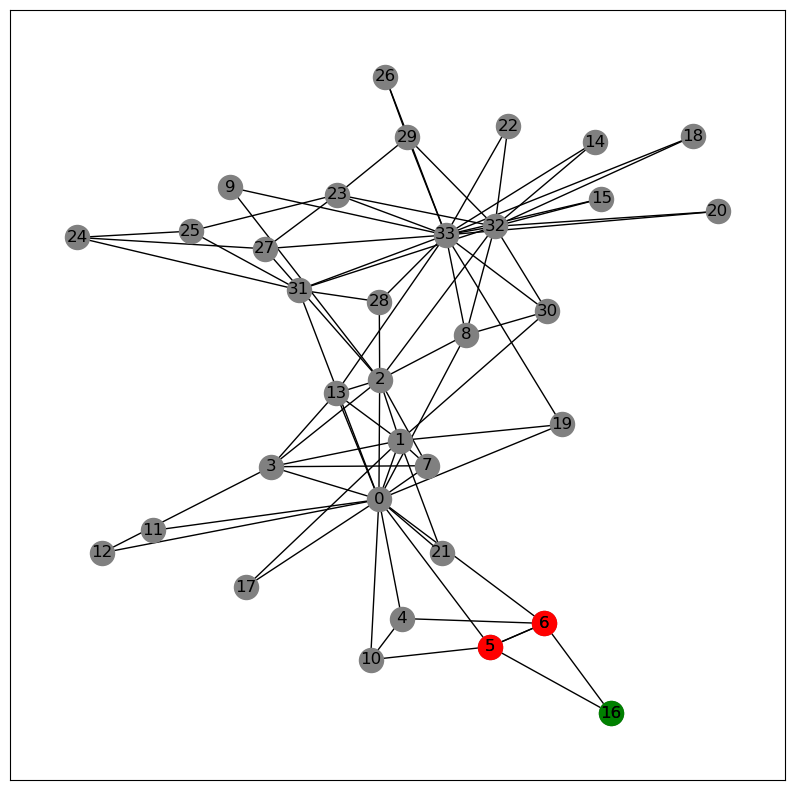

In [ ]:
G = nx.karate_club_graph()
print('Vértices:', G.nodes)

node = 16
print('\nVértice selecionado:', node)
print('Vizinhos do vértice selecionado:', list(G.neighbors(node)))

subset = list(G.neighbors(node))
pos = nx.spring_layout(G)
k = G.subgraph(subset)        # subgrafo dos vizinhos
nodei = G.subgraph(node)      # subgrafo de um único vértice (o NetworkX aceita tanto uma lista quanto um único vértice aqui)

plt.figure(figsize=(10, 10))
nx.draw_networkx(G, pos=pos, node_color='gray')
nx.draw_networkx(k, pos=pos, node_color='red')
nx.draw_networkx(nodei, pos=pos, node_color='green')
plt.show()

No desenho, o vértice de interesse aparece em **verde**, seus vizinhos diretos em **vermelho**, e o restante da rede em cinza — uma forma simples e eficaz de visualizar a **vizinhança** de um nó específico dentro de uma rede maior.

### O mesmo exemplo, para uma rede carregada a partir de dados reais

Vamos repetir essa análise para uma rede bem conhecida na literatura de redes complexas: a rede de **coaparições de personagens** no romance *Os Miseráveis*, de Victor Hugo — construída por Donald Knuth a partir de quantas vezes cada par de personagens aparece na mesma cena. Essa rede já vem incluída no próprio NetworkX, através da função `nx.les_miserables_graph()` — não precisamos carregar nenhum arquivo externo.

Vértices: ['Napoleon', 'Myriel', 'MlleBaptistine', 'MmeMagloire', 'CountessDeLo', 'Geborand', 'Champtercier', 'Cravatte', 'Count', 'OldMan', 'Valjean', 'Labarre', 'Marguerite', 'MmeDeR', 'Isabeau', 'Gervais', 'Listolier', 'Tholomyes', 'Fameuil', 'Blacheville', 'Favourite', 'Dahlia', 'Zephine', 'Fantine', 'MmeThenardier', 'Thenardier', 'Cosette', 'Javert', 'Fauchelevent', 'Bamatabois', 'Perpetue', 'Simplice', 'Scaufflaire', 'Woman1', 'Judge', 'Champmathieu', 'Brevet', 'Chenildieu', 'Cochepaille', 'Pontmercy', 'Boulatruelle', 'Eponine', 'Anzelma', 'Woman2', 'MotherInnocent', 'Gribier', 'MmeBurgon', 'Jondrette', 'Gavroche', 'Gillenormand', 'Magnon', 'MlleGillenormand', 'MmePontmercy', 'MlleVaubois', 'LtGillenormand', 'Marius', 'BaronessT', 'Mabeuf', 'Enjolras', 'Combeferre', 'Prouvaire', 'Feuilly', 'Courfeyrac', 'Bahorel', 'Bossuet', 'Joly', 'Grantaire', 'MotherPlutarch', 'Gueulemer', 'Babet', 'Claquesous', 'Montparnasse', 'Toussaint', 'Child1', 'Child2', 'Brujon', 'MmeHucheloup']

Vértic

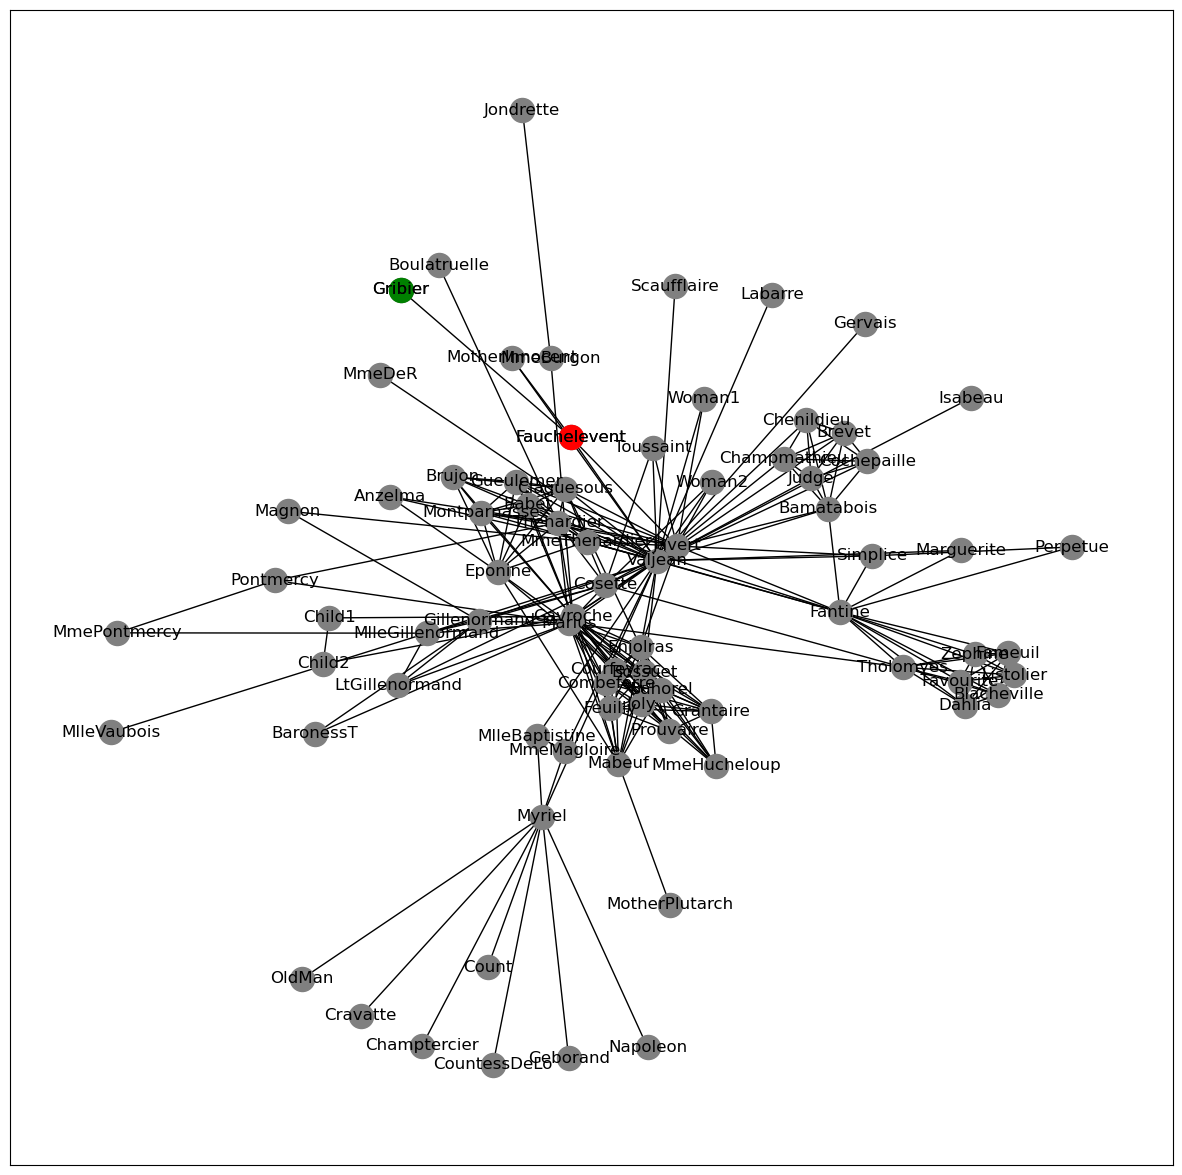

In [ ]:
G = nx.les_miserables_graph()   # rede de coaparições de personagens de "Os Miseráveis"
print('Vértices:', G.nodes)

node = 'Gribier'
print('\nVértice selecionado:', node)
print('Vizinhos do vértice selecionado:', list(G.neighbors(node)))

subset = list(G.neighbors(node))
pos = nx.spring_layout(G)
k = G.subgraph(subset)
nodei = G.subgraph(node)

plt.figure(figsize=(15, 15))
nx.draw_networkx(G, pos=pos, node_color='gray')
nx.draw_networkx(k, pos=pos, node_color='red')
nx.draw_networkx(nodei, pos=pos, node_color='green')
plt.show()

**Nota:** a versão original deste notebook carregava essa mesma rede a partir de um arquivo local (`nx.read_gml("data/lesmis.gml")`). Como o NetworkX já inclui essa rede clássica como um gerador embutido (assim como fizemos com `nx.karate_club_graph()`), usamos `nx.les_miserables_graph()` diretamente — o resultado é idêntico, mas sem depender de um arquivo externo que pode não estar disponível em todo ambiente.

## Conclusão

Neste notebook, cobrimos os conceitos e operações fundamentais para trabalhar com grafos usando o NetworkX:

- **construção**: adicionar/remover vértices e arestas, com ou sem peso, a partir de uma matriz de adjacências ou de uma lista de arestas;
- **visualização**: `nx.draw` combinado com algoritmos de layout (`spring_layout`, `circular_layout`, `fruchterman_reingold_layout`);
- **acesso**: consultar atributos de vértices e arestas específicas, iterar sobre todos eles, renomear vértices;
- **operadores**: extrair subgrafos, unir grafos (`disjoint_union`) ou compor grafos (`compose`);
- **conversão**: entre grafos direcionados e não direcionados, e entre grafos ponderados e binários (por limiar de peso);
- **leitura e escrita**: salvar e carregar redes a partir de arquivos;
- **componentes conectados**: identificar e extrair os blocos conectados de uma rede;
- **vizinhança**: consultar e visualizar os vizinhos diretos de um vértice.

Esses são os blocos de construção básicos sobre os quais se apoiam praticamente todas as análises mais avançadas de redes complexas — métricas de centralidade, detecção de comunidades, modelos de propagação (epidemias, informação), e muito mais — que veremos nas próximas aulas.

# Exercícios

Coloque os exercícios a seguir em um novo notebook com as soluções para ser enviado para avaliação.

## Exercício 1 — Rede de amizades

Crie um grafo não direcionado representando a seguinte rede de amizades.

| Pessoa | Amigos |
|---------|---------|
| Ana | Bruno, Carla |
| Bruno | Ana, Daniel, Eduardo |
| Carla | Ana, Daniel |
| Daniel | Bruno, Carla, Eduardo |
| Eduardo | Bruno, Daniel |

1. Construa o grafo utilizando o **NetworkX**.
2. Desenhe o grafo com os nomes dos vértices.
3. Imprima:
   - número de vértices;
   - número de arestas;
   - lista de vértices;
   - lista de arestas.
4. Remova a amizade entre **Bruno** e **Eduardo** e desenhe novamente o grafo.

---

## Exercício 2 — Mapa simplificado do metrô

Considere o seguinte mapa simplificado de estações:

```text
A ----- B ----- C
|       |
|       |
D ----- E ----- F
```

Cada ligação possui o seguinte tempo (em minutos):

| Ligação | Tempo |
|----------|------:|
| A–B | 3 |
| B–C | 2 |
| A–D | 5 |
| D–E | 4 |
| B–E | 6 |
| E–F | 3 |

1. Construa um **grafo ponderado** utilizando o NetworkX.
2. Desenhe o grafo exibindo os pesos das arestas.
3. Imprima o peso da ligação entre **D** e **E**.
4. Adicione uma nova ligação entre **C** e **F** com peso igual a 4.
5. Exiba novamente o grafo.

---

## Exercício 3 — Grafo a partir de uma matriz de adjacência

Considere a seguinte matriz de adjacência:

```python
A = np.array([
    [0,1,1,0,0,0],
    [1,0,1,1,0,0],
    [1,1,0,0,1,0],
    [0,1,0,0,1,1],
    [0,0,1,1,0,1],
    [0,0,0,1,1,0]
])
```

1. Construa o grafo correspondente.
2. Desenhe o grafo.
3. Imprima todos os vizinhos do vértice `2`.
4. Verifique se existe uma aresta entre os vértices `0` e `5`.
5. Calcule o grau de cada vértice.

---

## Exercício 4 — Rede de voos (grafo direcionado)

Considere as seguintes rotas aéreas:

| Origem | Destino |
|---------|----------|
| São Paulo | Rio de Janeiro |
| Rio de Janeiro | Brasília |
| Brasília | Salvador |
| Salvador | Recife |
| Recife | São Paulo |
| São Paulo | Brasília |

1. Construa um **grafo direcionado** (`DiGraph`).
2. Desenhe o grafo utilizando setas.
3. Imprima:
   - todos os vértices;
   - todas as arestas.
4. Adicione uma nova rota entre **Brasília** e **São Paulo**.
5. Imprima o número de ligações de entrada (*in-degree*) e de saída (*out-degree*) de cada cidade.

---

## Exercício 5 — Rede de páginas da Wikipédia

Considere as seguintes páginas da Wikipédia:

- Python
- NumPy
- Pandas
- Matplotlib
- NetworkX
- Ciência de Dados

Uma página possui um link para outra quando indicado abaixo:

```python
[
    ("Python", "NumPy"),
    ("Python", "Pandas"),
    ("Python", "Matplotlib"),
    ("Python", "NetworkX"),
    ("NumPy", "Pandas"),
    ("Pandas", "Matplotlib"),
    ("Pandas", "Ciência de Dados"),
    ("NetworkX", "Ciência de Dados"),
    ("Matplotlib", "Ciência de Dados")
]
```

1. Construa um **grafo direcionado** utilizando essa lista de arestas.
2. Desenhe o grafo.
3. Para cada página, imprima:
   - número de links de saída;
   - número de links de entrada.
4. Adicione uma ligação entre **NetworkX** e **Matplotlib**.
5. Renomeie todos os vértices para números inteiros utilizando `convert_node_labels_to_integers()`.
6. Qual página possui o maior número de links de entrada? E o maior número de links de saída?